In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes.experimental.approximation import FunctionSpace

## Block-push problem


$$
\min_{u(t), \mathbf{x}} \int_0^1 u^2(\tau) ~ d \tau, \qquad \text{subject to} \qquad
\begin{cases}
\dot{\mathbf{x}} &= f(t, \mathbf{x}, u) \\ 
\mathbf{x}(0) &= \begin{bmatrix} 0 & 0 \end{bmatrix}^T \\
\mathbf{x}(1) &= \begin{bmatrix} 1 & 0 \end{bmatrix}^T \\
\end{cases}
$$

where the dynamics are the double-integrator

$$
f(t, \mathbf{x}, u) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix} \mathbf{x} + \begin{bmatrix} 0 \\ 1 \end{bmatrix} u
$$

In [ ]:
t0, tf = 0.0, 1.0
nx, nu = 2, 1
x0, xf = np.array([0.0, 0.0]), np.array([1.0, 0.0])

n = 10  # number of intervals
tp = np.linspace(t0, tf, n + 1, endpoint=True)

# Set up the Simpson quadrature rule for the collocation method
quad_rule = arc.quadrature.simpson(n, a=t0, b=tf)

# Hermite-Simpson collocation - discretize `u` with piecewise
# linear functions and `x` with piecewise cubic functions
V_u = FunctionSpace.piecewise(
    kind="lagrange",
    degree=1,
    breakpoints=tp,
    nodes="lobatto",
    quad_rule=quad_rule,
    continuity=0,
)
V_x = FunctionSpace.piecewise(
    kind="hermite",
    degree=3,
    breakpoints=tp,
    quad_rule=quad_rule,
    continuity=1,
)


def f(x, u):
    return np.array([x[1], u[0]], like=x)


@arc.struct
class BlockPushParameters:
    u: np.ndarray  # control coefficients (n+1, nu)

    # The slope at the endpoints is defined by the dynamics
    # function, not free variables. The decision variables in
    # Hermite-Simpson are the node values only
    x: np.ndarray  # state node values (n+1, nx)

    @property
    def u_fn(self) -> np.ndarray:
        return V_u.function(self.u)

    @property
    def x_fn(self) -> np.ndarray:
        x_nodes = self.x
        u_nodes = self.u_fn(tp)

        # Interleave the states and the state derivatives
        # to form the derivative coefficients for the
        # Hermite spline.
        # NOTE: This should be cleaned up somehow - requires knowing
        # how the Hermite spline is constructed internally.
        rows = []
        for k in range(n + 1):
            rows.append(x_nodes[k : k + 1])
            x_dot = f(x_nodes[k], u_nodes[k])
            rows.append(x_dot[None, :])

        coeffs = np.concatenate(rows, axis=0)
        return V_x.function(coeffs)


def obj(params: BlockPushParameters) -> float:
    """Minimum-effort objective."""
    u = params.u_fn
    return u.dot(u)


def constr(params: BlockPushParameters) -> np.ndarray:
    """Collocation constraints."""
    t_mid = 0.5 * (tp[:-1] + tp[1:])

    # State derivative at the midpoint, computed by interpolation
    # of the Hermite spline at the midpoint.
    x_dot_interp = params.x_fn(t_mid, deriv=1)

    # Vectorize the dynamics evaluation over the midpoints
    u_mid = params.u_fn(t_mid)
    x_mid = params.x_fn(t_mid)
    x_dot_eval = arc.vmap(f, in_axes=(0, 0))(x_mid, u_mid)
    defect = x_dot_interp - x_dot_eval

    # Apply boundary conditions
    x0_val = params.x_fn(np.array([t0]))
    xf_val = params.x_fn(np.array([tf]))
    return np.concatenate([defect, x0_val - x0, xf_val - xf], axis=0).ravel()



u_guess = np.zeros((n + 1, nu))
x_guess = x0 + (tp[:, None] - t0) * (xf - x0) / (tf - t0)

init_params = BlockPushParameters(u=u_guess, x=x_guess)
res = arc.minimize(obj, x0=init_params, constr=constr)
sol = res.x

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      792
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       66

Total number of variables............................:       33
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       24
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.50e+00 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

Max absolute error: 5.5511e-16


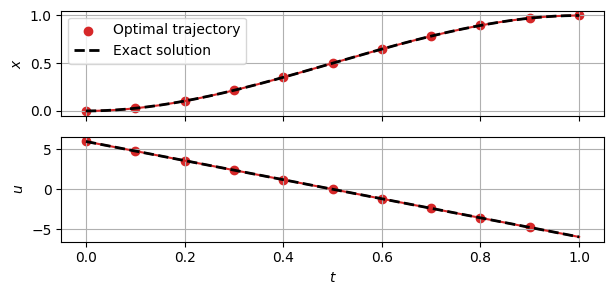

In [63]:
import matplotlib.pyplot as plt


def x_ex(t):
    return 3 * t**2 - 2 * t**3


def u_ex(t):
    return 6 - 12 * t


t_plt = np.linspace(t0, tf, 1000)
x_plt = sol.x_fn(t_plt)
u_plt = sol.u_fn(t_plt)

print(f"Max absolute error: {max(abs(x_plt[:, 0] - x_ex(t_plt))):.4e}")

fig, ax = plt.subplots(2, 1, figsize=(7, 3), sharex=True)
ax[0].scatter(tp, sol.x_fn(tp)[:, 0], c="tab:red", label="Optimal trajectory")
ax[0].plot(t_plt, x_plt[:, 0], c="tab:red")
ax[0].plot(t_plt, x_ex(t_plt), "k--", lw=2, label="Exact solution")
ax[0].legend()
ax[0].grid()
ax[0].set_ylabel(r"$x$")
ax[1].scatter(tp[:-1], sol.u_fn(tp[:-1]), c="tab:red")
ax[1].plot(t_plt, u_plt, c="tab:red")
ax[1].plot(t_plt, u_ex(t_plt), "k--", lw=2)
ax[1].grid()
ax[1].set_ylabel(r"$u$")
ax[1].set_xlabel(r"$t$")

plt.show()

## Cart-Pole swingup